# Lab 6.1 — Introduction to LangGraph

## Introduction

This is the **first lab** in the LangGraph module. LangGraph lets you build **stateful, graph-based agent workflows** — nodes are Python functions, edges define the flow, and a shared **State** object carries data between steps.

In this lab, you will build a minimal graph from scratch: define state with a **reducer**, add a node that generates random phrases, connect it with edges, compile the graph, and expose it through a Gradio chat UI.

You will also set up **LangSmith** for tracing so you can inspect every graph run in the browser.

Before starting, make sure you have:
- Completed earlier modules (Foundations through OpenAI Agents SDK)
- Installed LangGraph and dependencies from the project `requirements.txt`
- An OpenAI API key in your `.env` file

---

## Intention (Learning Objectives)

By the end of this lab, you should be able to:

1. **Set up LangSmith tracing** — configure environment variables for observability
2. **Understand `Annotated` and reducers** — tell LangGraph how to merge state updates using `add_messages`
3. **Define a State object** — use a Pydantic `BaseModel` with annotated fields
4. **Build a graph** — create nodes, add edges (`START` → node → `END`), and compile
5. **Visualize the graph** — render the graph structure with Mermaid
6. **Invoke the graph from a UI** — wire `graph.invoke()` into a Gradio `ChatInterface`

---

## Lab Structure

| Part | Content |
|------|---------|
| **Part 1** | Set up LangSmith for tracing |
| **Part 2** | Imports, constants, and environment setup |
| **Part 3** | `Annotated`, reducers, and a quick demo |
| **Part 4** | Build the graph — State, nodes, edges, compile, visualize |
| **Part 5** | Launch the Gradio chat interface |

> **Note:** Run cells top to bottom in order.

## Part 1 — Set Up LangSmith

LangSmith provides tracing and debugging for LangGraph runs. Follow these steps before building your graph:

1. Go to [https://langsmith.com](https://langsmith.com)
2. **Sign up** and **log in**
3. Click **"+ Project"** and create a project
4. Go to the **"Tracing"** menu
5. Focus on the **"Configure environment"** section and switch the tab to **".env"**
6. Copy the whole env block and paste it into your `.env` file
7. Click **"Generate API Key"**
8. Replace the API key value in your `.env` file

After setup, traces will appear at [https://smith.langchain.com/](https://smith.langchain.com/)

## Part 2 — Setup

Import LangGraph, Gradio, and supporting libraries. Define word lists for the random phrase generator, then load your environment variables.

In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel
import random


In [2]:
# Some useful constants

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [3]:
load_dotenv(override=True)

True

## Part 3 — Annotated Types & Reducers

LangGraph requires `Annotated` on State fields to specify a **reducer** — the function that merges new values into existing state. For message lists, the built-in `add_messages` reducer handles the common case.

Run the cell below as a quick warm-up, then review the concept before defining your State.

In [4]:
def shout(text: Annotated[str, "something to be shouted"]) -> str:
    print(text.upper())
    return text.upper()

shout("hello")

HELLO


'HELLO'

### A word about `Annotated`

Type hinting lets you specify types in Python:

`my_favorite_things: List`

`Annotated` adds extra metadata that frameworks can use:

`my_favorite_things: Annotated[List, "these are a few of mine"]`

LangGraph uses this to know which **reducer** to call when updating state. That is why our State looks like:

`messages: Annotated[list, add_messages]`

## Part 4 — Build the Graph

Follow the five LangGraph steps: define State, create a graph builder, add a node, add edges, and compile.

### Step 1 — Define the State

Use a Pydantic `BaseModel` with an annotated `messages` field.

In [5]:
class State(BaseModel):
        
    messages: Annotated[list, add_messages]

### Step 2 — Start the Graph Builder

In [6]:
graph_builder = StateGraph(State)

### Step 3 — Create a Node

A node is any Python function. It receives the current state and returns a new state update. The reducer merges the result automatically.

In [7]:
def our_first_node(old_state: State) -> State:

    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]

    new_state = State(messages=messages)

    return new_state

graph_builder.add_node("first_node", our_first_node)

### Step 4 — Create Edges

Connect `START` → `first_node` → `END` to define the execution flow.

In [8]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

### Step 5 — Compile & Visualize

Compile the graph and render its structure as a Mermaid diagram.

In [9]:
graph = graph_builder.compile()

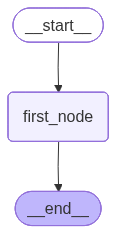

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Part 5 — Gradio Chat Interface

Wrap `graph.invoke()` in a `chat` function and launch a Gradio UI. Each user message triggers one graph run.

In [ ]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='dfsf', additional_kwargs={}, response_metadata={}, id='bc183b3e-9ea7-44a0-b64d-ba6f87ce6144'), AIMessage(content='Rainbows are outrageous', additional_kwargs={}, response_metadata={}, id='0ff4b498-5cf9-4b91-ad3c-c933c929ff62')]}
{'messages': [HumanMessage(content='dsfs', additional_kwargs={}, response_metadata={}, id='f916b8c5-d39d-42f8-9099-ba3ed4cf1288'), AIMessage(content='Pickles are squishy', additional_kwargs={}, response_metadata={}, id='1dcc5d9a-6002-46f4-b25b-1538dc862483')]}


---

## Next Steps

Chat with your graph and review the traces on LangSmith:

**https://smith.langchain.com/**

In [Lab 6.2](6_lab2.ipynb), you will add LLM tool calling, memory, and SQLite checkpointing.